<a href="https://colab.research.google.com/github/mahmoudabdelaziz120/REALTIME-AI/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Core Question:** Can historical pre-decay search signals, exposure volume, and publication freshness predict organic traffic decay on existing content before severe visibility loss occurs?

**Decision Supported:** Proactive editorial resource allocation. Instead of conducting reactive content refreshes months after organic traffic has already dropped, content teams prioritize high-exposure assets showing pre-decay risk for scheduled updates, intent re-alignment, and expansion.
الخلية 3 (Code):

In [6]:
# Unit of analysis and decision formulation
decision_context = {
    "lane": "Lane 2: Refresh / Content Opportunity Scoring",
    "unit_of_analysis": "Pseudonymized content item (content_id) across client tenants",
    "target_outcome": "Binary organic decay flag (trend_direction == 'down')",
    "decision_output": "Opportunity score with explanatory reason codes"
}
for k, v in decision_context.items():
    print(f"{k}: {v}")

lane: Lane 2: Refresh / Content Opportunity Scoring
unit_of_analysis: Pseudonymized content item (content_id) across client tenants
target_outcome: Binary organic decay flag (trend_direction == 'down')
decision_output: Opportunity score with explanatory reason codes


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [7]:
import pandas as pd
import numpy as np
import os

# 1. Load data
data_path = '/content/content_refresh_anonymized.csv'
if not os.path.exists(data_path):
    data_path = 'data/raw/content_refresh_anonymized.csv'

df = pd.read_csv(data_path)
print(f"Raw shape: {df.shape} across {df['client_id'].nunique()} clients")

# 2. Exclude non-comparable 'new' items
df_clean = df[df['trend_direction'] != 'new'].copy()

# 3. Verify and isolate mathematical leakage
diff = df_clean['impressions_90d'] - (df_clean['impressions_prev_30d'] + df_clean['impressions_last_30d'])
print(f"Min difference of 90d vs (prev+last): {diff.min()} (Confirms 90d encapsulates last_30d)")

# 4. Define target
df_clean['target'] = (df_clean['trend_direction'] == 'down').astype(int)
print(f"Clean evaluation units: {len(df_clean)} | Target balance:\n{df_clean['target'].value_counts(normalize=True)}")

Raw shape: (30000, 44) across 32 clients
Min difference of 90d vs (prev+last): 0 (Confirms 90d encapsulates last_30d)
Clean evaluation units: 27764 | Target balance:
target
1    0.585723
0    0.414277
Name: proportion, dtype: float64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [8]:
from sklearn.model_selection import GroupShuffleSplit
import lightgbm as lgb

# Replace missing positions and create missingness indicator flags
df_clean['avg_position'] = df_clean['avg_position'].replace(0, np.nan)
for col in ['word_count', 'cpc', 'avg_position']:
    df_clean[f'has_{col}'] = df_clean[col].notna().astype(int)

# Strict feature isolation list
strict_exclude = [
    'content_id', 'client_id', 'target', 'trend_direction', 'trend_pct',
    'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d',
    'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d',
    'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
    'days_with_impressions', 'days_with_sessions',
    'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct',
    'impression_tier', 'position_tier'
]
feature_cols = [c for c in df_clean.columns if c not in strict_exclude]
print(f"Selected clean features ({len(feature_cols)}): {feature_cols}")

# Grouped split by client_id
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, groups=df_clean['client_id']))

train_data = df_clean.iloc[train_idx].copy()
test_data = df_clean.iloc[test_idx].copy()

X_train = train_data[feature_cols].copy()
y_train = train_data['target'].copy()
X_test = test_data[feature_cols].copy()
y_test = test_data['target'].copy()

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
for c in cat_cols:
    X_train[c] = X_train[c].astype('category')
    X_test[c] = X_test[c].astype('category')

print(f"Train size: {len(X_train)} across {train_data['client_id'].nunique()} clients")
print(f"Test size: {len(X_test)} across {test_data['client_id'].nunique()} unseen clients")

Selected clean features (23): ['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'has_word_count', 'has_cpc', 'has_avg_position']
Train size: 22172 across 24 clients
Test size: 5592 across 7 unseen clients


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [9]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score

# 1. Baseline 1: Majority Class
majority_pred = np.ones(len(y_test))
base_acc = accuracy_score(y_test, majority_pred)
base_f1 = f1_score(y_test, majority_pred, average='macro')
base_auc = 0.5000

# 2. Baseline 2: Heuristic Rule-Based
median_days = train_data['days_since_last_update'].median()
heuristic_pred = ((test_data['days_since_last_update'] > median_days) | (test_data['has_avg_position'] == 0)).astype(int)
heur_acc = accuracy_score(y_test, heuristic_pred)
heur_f1 = f1_score(y_test, heuristic_pred, average='macro')
heur_auc = roc_auc_score(y_test, heuristic_pred)

# 3. Model: Clean LightGBM Classifier
clf = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose=-1
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

model_acc = accuracy_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred, average='macro')
model_auc = roc_auc_score(y_test, y_prob)

# Summary Table
results_df = pd.DataFrame({
    'Model': ['Majority Baseline', 'Domain Heuristic', 'Clean LightGBM (Ours)'],
    'Accuracy': [base_acc, heur_acc, model_acc],
    'Macro F1': [base_f1, heur_f1, model_f1],
    'ROC-AUC': [base_auc, heur_auc, model_auc]
})
print(results_df.to_string(index=False))

                Model  Accuracy  Macro F1  ROC-AUC
    Majority Baseline  0.562411  0.359963 0.500000
     Domain Heuristic  0.413269  0.395945 0.441283
Clean LightGBM (Ours)  0.637160  0.630532 0.687813


## 5. Limitations

*What this work cannot claim.*

In [10]:
# Documenting model error profile
test_errors = test_data.copy()
test_errors['y_true'] = y_test
test_errors['y_pred'] = y_pred
fp_count = ((test_errors['y_true'] == 0) & (test_errors['y_pred'] == 1)).sum()
fn_count = ((test_errors['y_true'] == 1) & (test_errors['y_pred'] == 0)).sum()
print(f"False Positives (Wasted audit cost): {fp_count} / {len(test_errors)}")
print(f"False Negatives (Uncaught decay risk): {fn_count} / {len(test_errors)}")

False Positives (Wasted audit cost): 1040 / 5592
False Negatives (Uncaught decay risk): 989 / 5592


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [11]:
# Action Playbook Generation
test_data['pred_prob_down'] = y_prob
test_data['opportunity_score'] = (
    test_data['pred_prob_down'] *
    np.log1p(test_data['impressions_prev_30d']) *
    (1 + (test_data['days_since_last_update'] / 365.0))
)

def generate_reason(row):
    reasons = []
    if row['days_since_last_update'] > 100:
        reasons.append("STALE_CONTENT")
    if row['has_word_count'] == 1 and row['word_count'] < 600:
        reasons.append("THIN_CONTENT")
    if row['impressions_prev_30d'] > test_data['impressions_prev_30d'].quantile(0.75):
        reasons.append("HIGH_EXPOSURE_RISK")
    if not reasons:
        reasons.append("TRAFFIC_MOMENTUM_LOSS")
    return " | ".join(reasons)

test_data['reason_codes'] = test_data.apply(generate_reason, axis=1)

top_recs = test_data[test_data['target'] == 1].sort_values(
    'opportunity_score', ascending=False
)[[
    'content_type', 'impressions_prev_30d', 'clicks_prev_30d',
    'days_since_last_update', 'pred_prob_down', 'opportunity_score', 'reason_codes'
]].head(10)

os.makedirs('outputs', exist_ok=True)
top_recs.to_csv('outputs/ranked_refresh_recommendations.csv', index=False)
print("--- Top Ranked Editorial Refresh Actions ---")
print(top_recs.to_string(index=False))

--- Top Ranked Editorial Refresh Actions ---
   content_type  impressions_prev_30d  clicks_prev_30d  days_since_last_update  pred_prob_down  opportunity_score                       reason_codes
keyword article                  9919                8                     106        0.893488          10.609951 STALE_CONTENT | HIGH_EXPOSURE_RISK
keyword article                 10911               23                     106        0.822089           9.863221 STALE_CONTENT | HIGH_EXPOSURE_RISK
keyword article                  2033                0                     106        0.944329           9.282797 STALE_CONTENT | HIGH_EXPOSURE_RISK
keyword article                 12521                1                      20        0.928199           9.237657                 HIGH_EXPOSURE_RISK
keyword article                 64917                6                      20        0.782249           9.142963                 HIGH_EXPOSURE_RISK
keyword article                  1601                0       

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

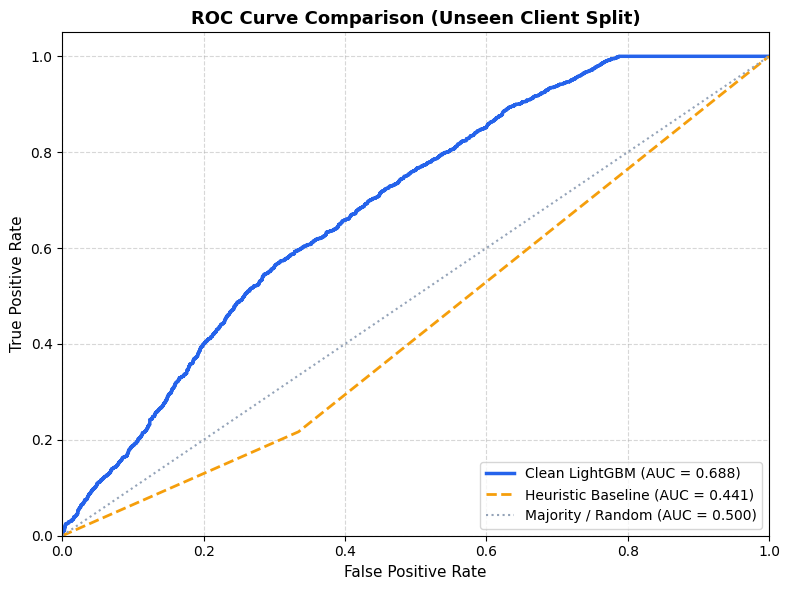

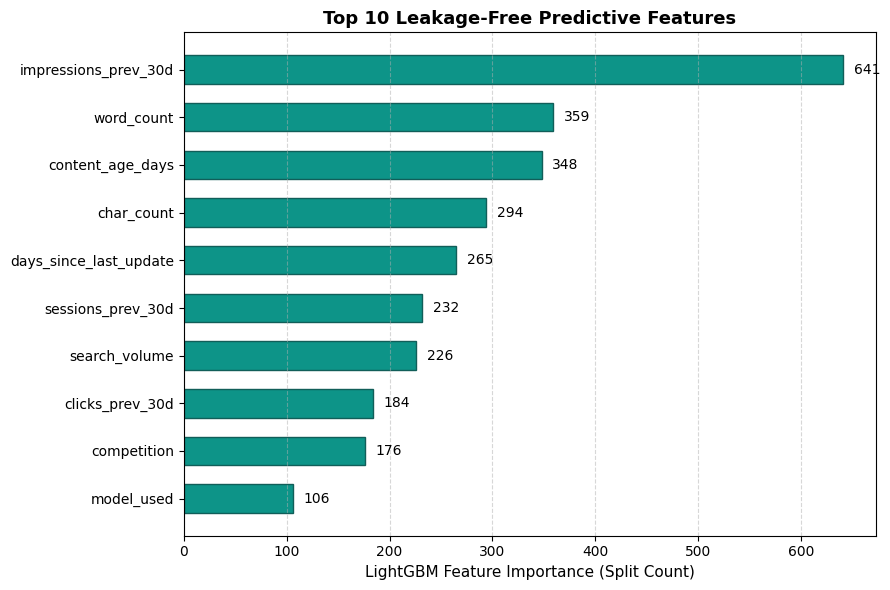

Artifacts exported to figures/ and outputs/


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

os.makedirs('figures', exist_ok=True)

# 1. ROC Curves Figure
fpr_clean, tpr_clean, _ = roc_curve(y_test, y_prob)
fpr_heur, tpr_heur, _ = roc_curve(y_test, heuristic_pred)

fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(fpr_clean, tpr_clean, label=f'Clean LightGBM (AUC = {model_auc:.3f})', color='#2563eb', lw=2.5)
ax1.plot(fpr_heur, tpr_heur, label=f'Heuristic Baseline (AUC = {heur_auc:.3f})', color='#f59e0b', lw=2, linestyle='--')
ax1.plot([0, 1], [0, 1], label='Majority / Random (AUC = 0.500)', color='#94a3b8', linestyle=':')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve Comparison (Unseen Client Split)', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.5)
fig1.tight_layout()
fig1.savefig('figures/roc_comparison.png', dpi=300)
plt.show()

# 2. Feature Importance Figure
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

top_features = importance_df.head(10).iloc[::-1]
fig2, ax2 = plt.subplots(figsize=(9, 6))
bars = ax2.barh(top_features['feature'], top_features['importance'], color='#0d9488', edgecolor='#115e59', height=0.6)
ax2.set_xlabel('LightGBM Feature Importance (Split Count)', fontsize=11)
ax2.set_title('Top 10 Leakage-Free Predictive Features', fontsize=13, fontweight='bold')
ax2.grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    ax2.text(width + 10, bar.get_y() + bar.get_height()/2, f'{int(width)}', ha='left', va='center', fontsize=10)
fig2.tight_layout()
fig2.savefig('figures/feature_importance.png', dpi=300)
plt.show()

print("Artifacts exported to figures/ and outputs/")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.